In [44]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

In [45]:
import pandas as pd

traffic = pd.read_csv("../datasets/traffic.csv")

traffic.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [46]:
traffic.info()

<class 'pandas.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   DateTime  48120 non-null  str  
 1   Junction  48120 non-null  int64
 2   Vehicles  48120 non-null  int64
 3   ID        48120 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.5 MB


In [47]:
traffic.describe()

,Junction,Vehicles,ID
count,48120.000000,48120.000000,4.812000e+04
mean,2.180549,22.791334,2.016330e+10
std,0.966955,20.750063,5.944854e+06
min,1.000000,1.000000,2.015110e+10
25%,1.000000,9.000000,2.016042e+10
50%,2.000000,15.000000,2.016093e+10
75%,3.000000,29.000000,2.017023e+10
max,4.000000,180.000000,2.017063e+10


In [48]:
traffic.columns

Index(['DateTime', 'Junction', 'Vehicles', 'ID'], dtype='str')

In [49]:
traffic.isnull().sum()

DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

In [50]:
traffic.info()

<class 'pandas.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   DateTime  48120 non-null  str  
 1   Junction  48120 non-null  int64
 2   Vehicles  48120 non-null  int64
 3   ID        48120 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.5 MB


In [51]:
traffic.describe()

,Junction,Vehicles,ID
count,48120.000000,48120.000000,4.812000e+04
mean,2.180549,22.791334,2.016330e+10
std,0.966955,20.750063,5.944854e+06
min,1.000000,1.000000,2.015110e+10
25%,1.000000,9.000000,2.016042e+10
50%,2.000000,15.000000,2.016093e+10
75%,3.000000,29.000000,2.017023e+10
max,4.000000,180.000000,2.017063e+10


In [52]:
traffic.columns

Index(['DateTime', 'Junction', 'Vehicles', 'ID'], dtype='str')

In [53]:
traffic.isnull().sum()

DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

In [54]:
traffic.duplicated().sum()

np.int64(0)

In [55]:
traffic.shape

(48120, 4)

In [56]:
traffic["DateTime"] = pd.to_datetime(traffic["DateTime"])
traffic.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [57]:
traffic["Hour"] = traffic["DateTime"].dt.hour
traffic["Day"] = traffic["DateTime"].dt.day
traffic["Month"] = traffic["DateTime"].dt.month
traffic["Weekday"] = traffic["DateTime"].dt.dayofweek

traffic.head()

,DateTime,Junction,Vehicles,ID,Hour,Day,Month,Weekday
0,2015-11-01 00:00:00,1,15,20151101001,0,1,11,6
1,2015-11-01 01:00:00,1,13,20151101011,1,1,11,6
2,2015-11-01 02:00:00,1,10,20151101021,2,1,11,6
3,2015-11-01 03:00:00,1,7,20151101031,3,1,11,6
4,2015-11-01 04:00:00,1,9,20151101041,4,1,11,6


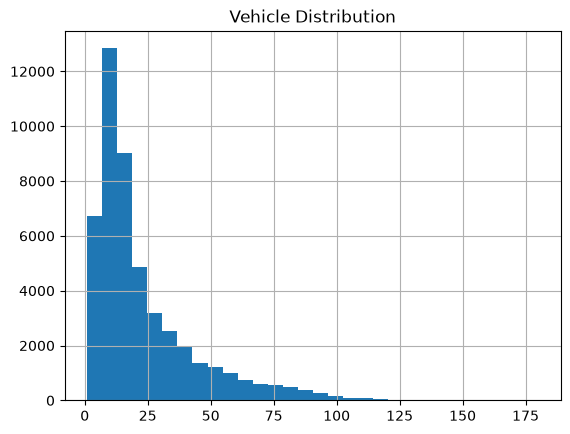

In [58]:
import matplotlib.pyplot as plt

traffic["Vehicles"].hist(bins=30)
plt.title("Vehicle Distribution")
plt.show()

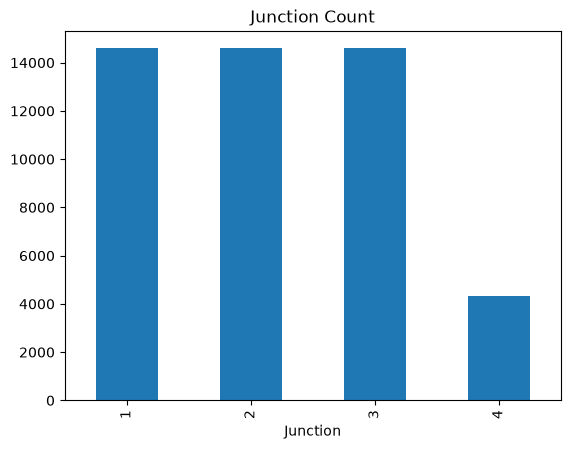

In [59]:
traffic["Junction"].value_counts().plot(kind="bar")
plt.title("Junction Count")
plt.show()

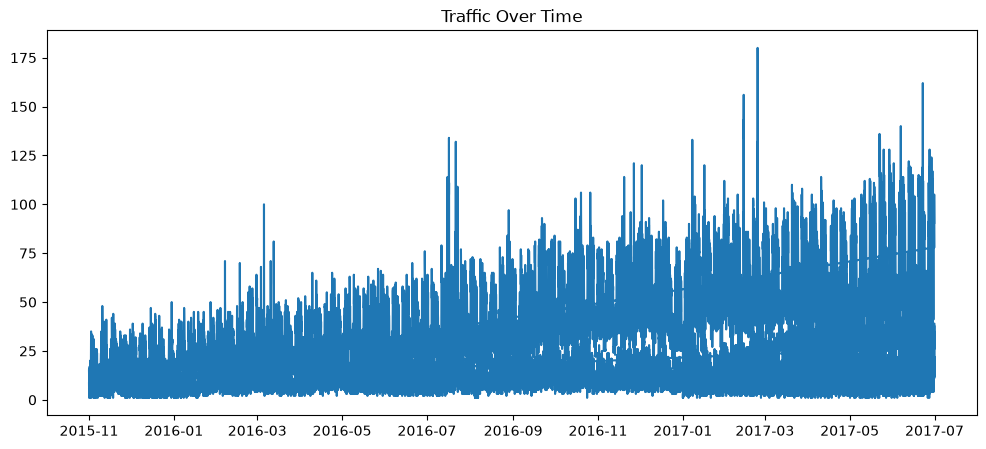

In [60]:
plt.figure(figsize=(12,5))
plt.plot(traffic["DateTime"], traffic["Vehicles"])
plt.title("Traffic Over Time")
plt.show()

Traffic Prediction using Random Forest

In [61]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [62]:
import pandas as pd

ttraffic = pd.read_csv("../datasets/traffic.csv")

traffic["DateTime"] = pd.to_datetime(traffic["DateTime"])

traffic["Hour"] = traffic["DateTime"].dt.hour
traffic["Day"] = traffic["DateTime"].dt.day
traffic["Month"] = traffic["DateTime"].dt.month
traffic["Weekday"] = traffic["DateTime"].dt.weekday

traffic.head()

,DateTime,Junction,Vehicles,ID,Hour,Day,Month,Weekday
0,2015-11-01 00:00:00,1,15,20151101001,0,1,11,6
1,2015-11-01 01:00:00,1,13,20151101011,1,1,11,6
2,2015-11-01 02:00:00,1,10,20151101021,2,1,11,6
3,2015-11-01 03:00:00,1,7,20151101031,3,1,11,6
4,2015-11-01 04:00:00,1,9,20151101041,4,1,11,6


In [63]:
from sklearn.model_selection import train_test_split

X = traffic[["Hour","Day","Month","Weekday","Junction"]]

y = traffic["Vehicles"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(38496, 5)
(9624, 5)


In [64]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Training Completed")

Training Completed


In [65]:
predictions = model.predict(X_test)

predictions[:10]

array([ 7.68, 54.6 ,  6.99, 10.91, 18.94, 13.51,  7.25, 14.84, 13.98,
       22.32])

In [66]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5
r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 4.663848711554447
RMSE: 7.3227818738784185
R2 Score: 0.8684245790947671


In [67]:
import joblib

joblib.dump(model, "traffic_model.pkl")

print("Model Saved")

Model Saved


In [68]:
import os

print(os.listdir())

['accident-model-pkl.ipynb', 'hospital_score.py', 'predict_severity.py', 'traffic-model-pkl.ipynb', 'traffic_model.pkl']
